In [3]:
# Imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Set matplotlib style
plt.style.use('ggplot')

print("Loading data and model pipeline...")

# Load the data
df = pd.read_csv('data/processed/features.csv')
df['lyrics'] = df['lyrics'].fillna("")

# Recreate the exact numeric features list
numeric_features = ['avg_sentence_length', 'count_verbs', 'count_adjectives', 'count_pronouns']
freq_features = [col for col in df.columns if col.startswith('freq_')]
numeric_features.extend(freq_features)

# X and y
X = df[numeric_features + ['lyrics']]
y = df['artist']

# Recreating the same test split used in training
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Load saved Logistic Regression model
model_pipeline = joblib.load('models/logistic_regression_main.joblib')

print(f"Success! Model and test data ({len(X_test)} samples) loaded.")

Loading data and model pipeline...
Success! Model and test data (16 samples) loaded.


Generating Confusion Matrix



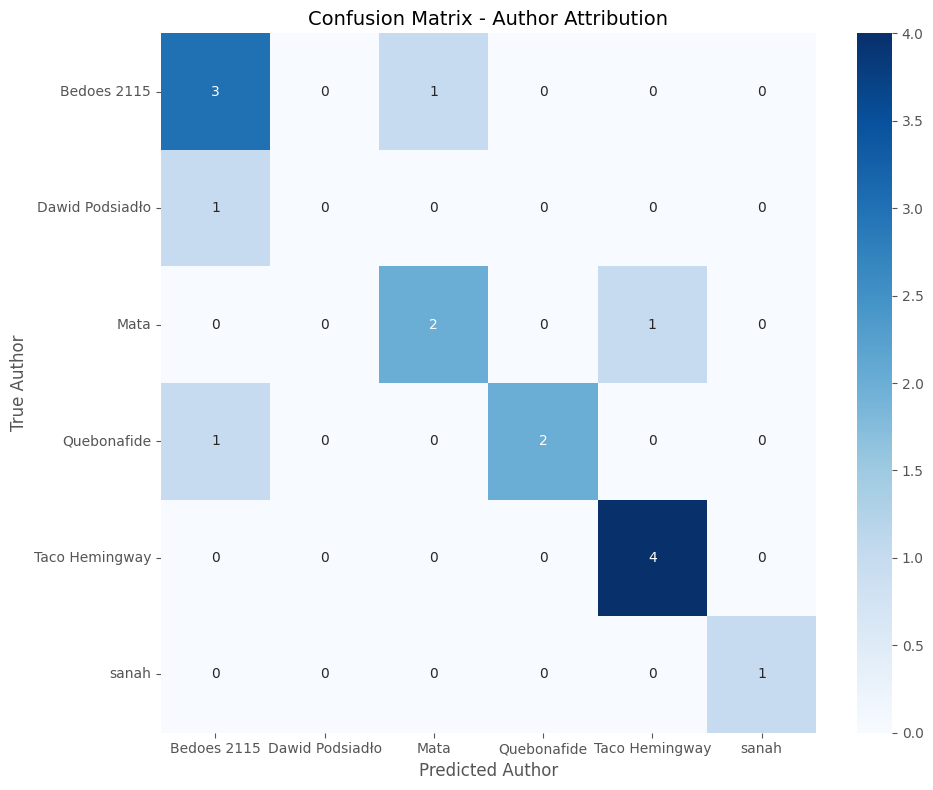

In [4]:
print("Generating Confusion Matrix\n")

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model_pipeline.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=model_pipeline.classes_, 
    yticklabels=model_pipeline.classes_
)
plt.title('Confusion Matrix - Author Attribution', fontsize=14)
plt.ylabel('True Author', fontsize=12)
plt.xlabel('Predicted Author', fontsize=12)
plt.tight_layout()
plt.show()

Extracting Top-20 features for each author



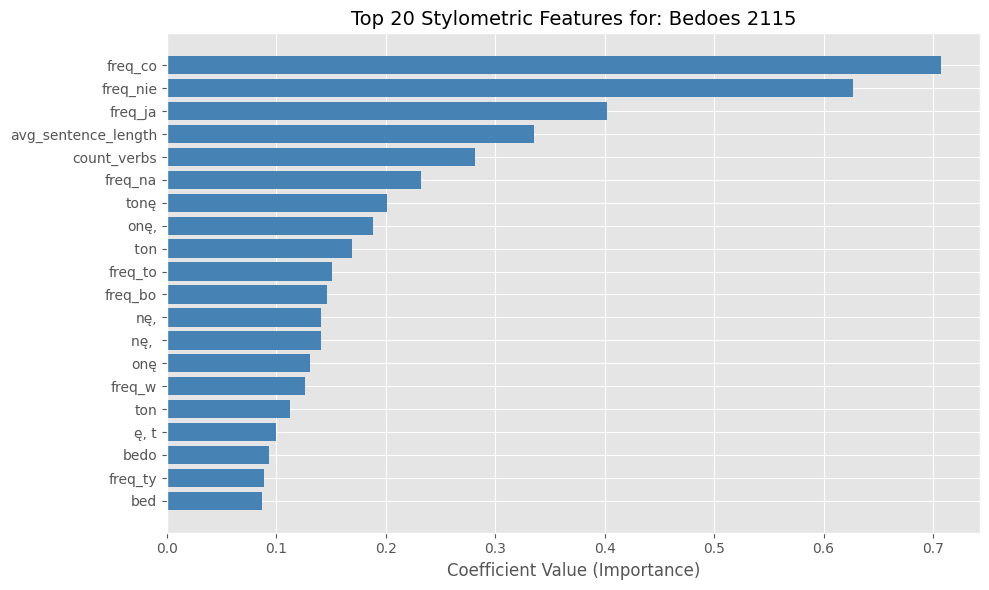

-> Generated chart for Bedoes 2115


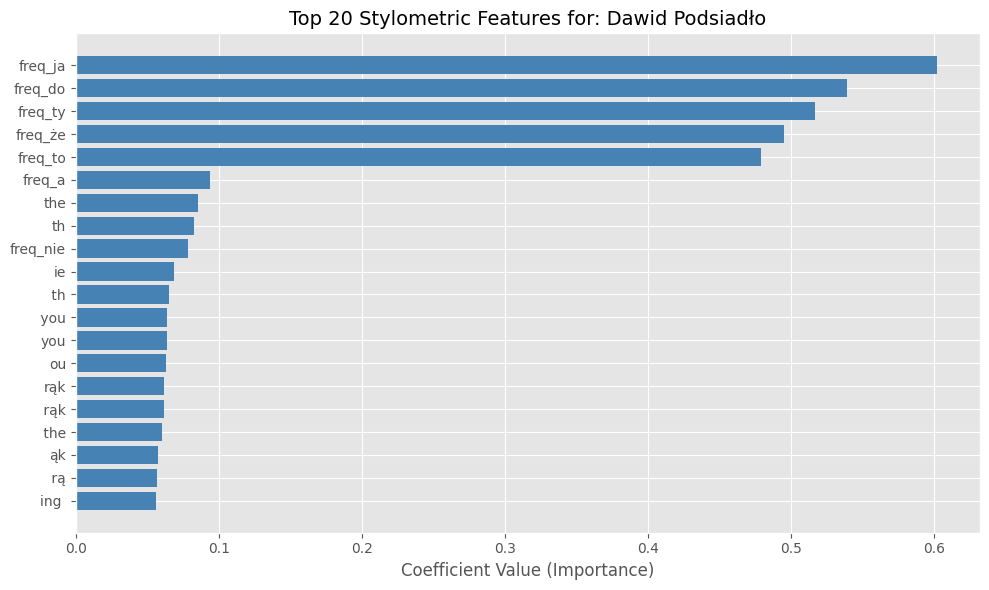

-> Generated chart for Dawid Podsiadło


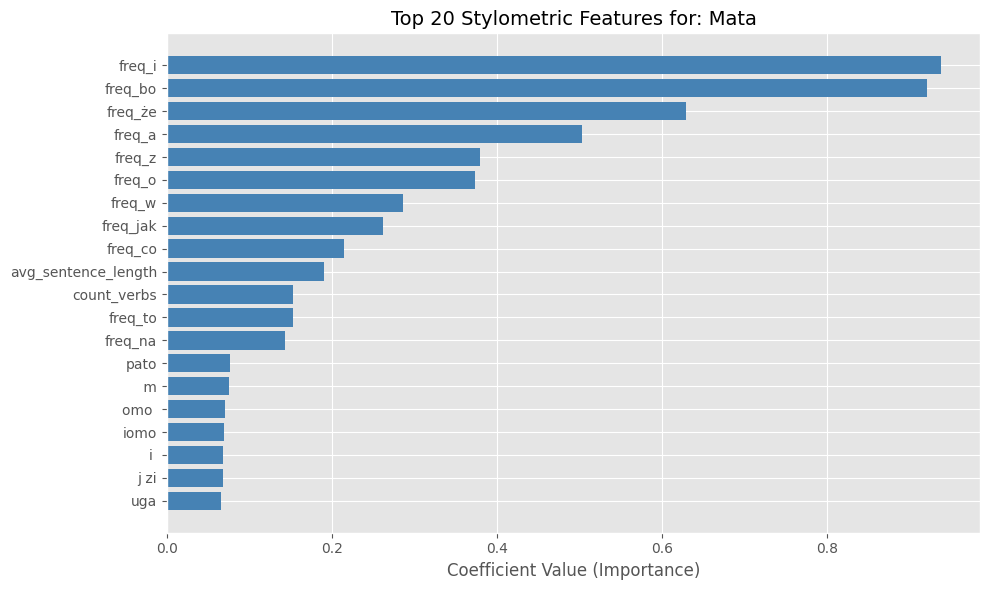

-> Generated chart for Mata


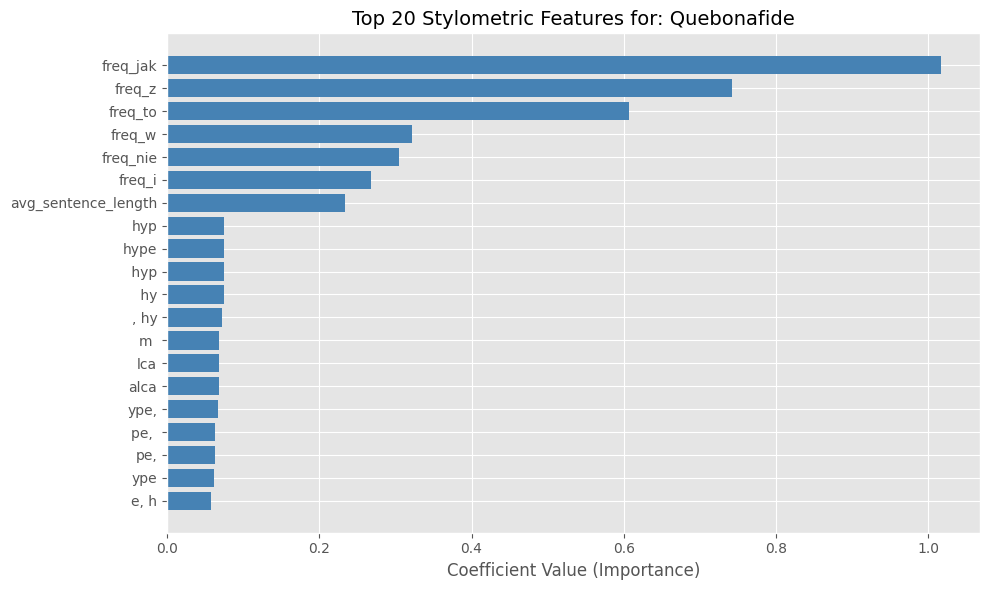

-> Generated chart for Quebonafide


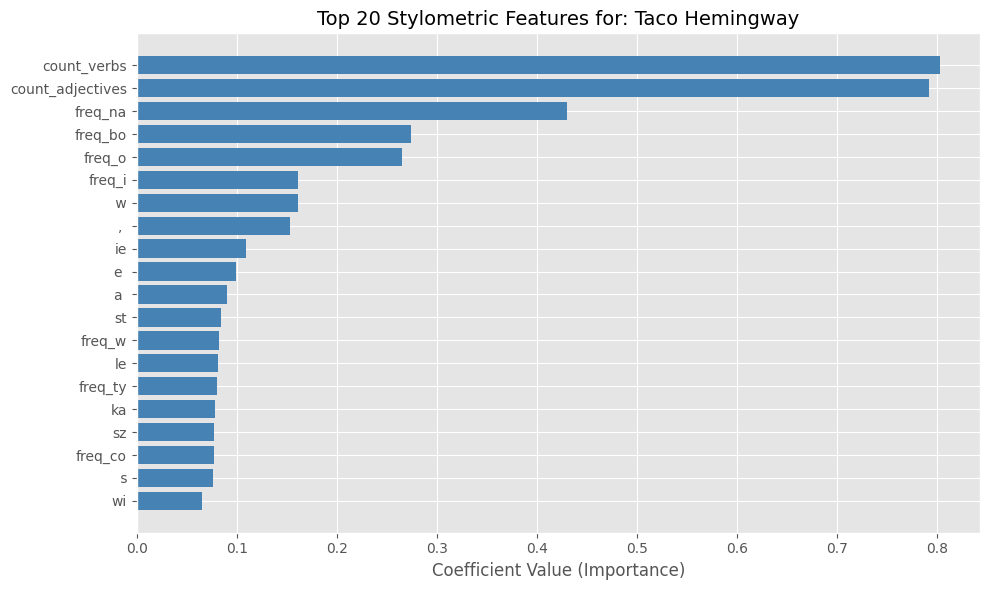

-> Generated chart for Taco Hemingway


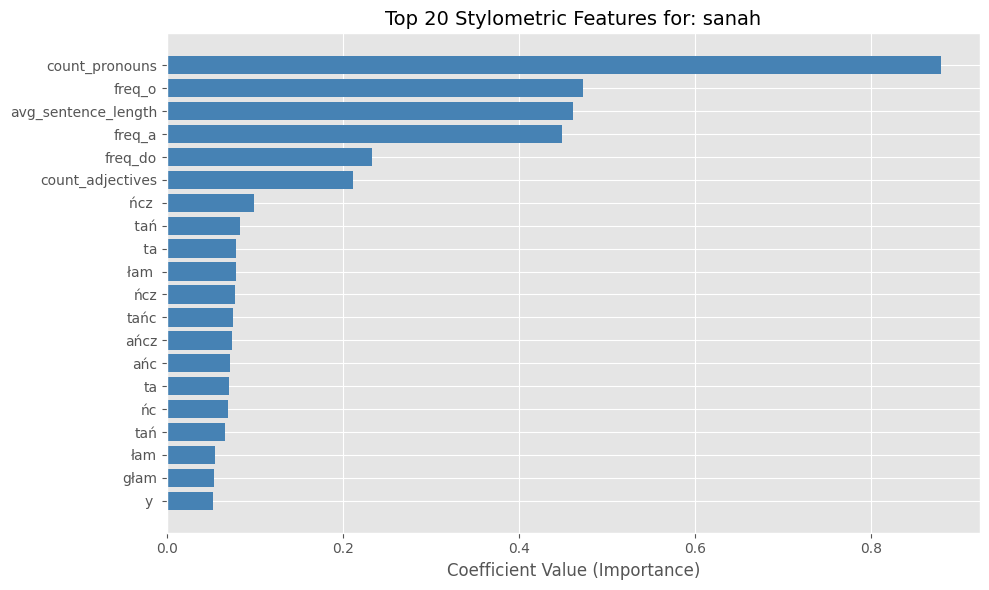

-> Generated chart for sanah


In [5]:
print("Extracting Top-20 features for each author\n")

# Extracting trained classifier and preprocessor from the pipeline
classifier = model_pipeline.named_steps['classifier']
preprocessor = model_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

# Clean up
clean_feature_names = [name.split('__')[-1] for name in feature_names]

classes = classifier.classes_
coefficients = classifier.coef_

# Iterating over each author and plot their top 20 features
for i, author in enumerate(classes):
    top_indices = np.argsort(coefficients[i])[-20:]
    
    top_features = [clean_feature_names[j] for j in top_indices]
    top_coefs = coefficients[i][top_indices]
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_features, top_coefs, color='steelblue')
    plt.title(f'Top 20 Stylometric Features for: {author}', fontsize=14)
    plt.xlabel('Coefficient Value (Importance)', fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"-> Generated chart for {author}")

Starting Accuracy vs. Sample Length Experiment...

Accuracy for 50 words: 0.1250
Accuracy for 100 words: 0.1875
Accuracy for 200 words: 0.1875
Accuracy for 300 words: 0.4375
Accuracy for 400 words: 0.5000
Accuracy for 500 words: 0.7500


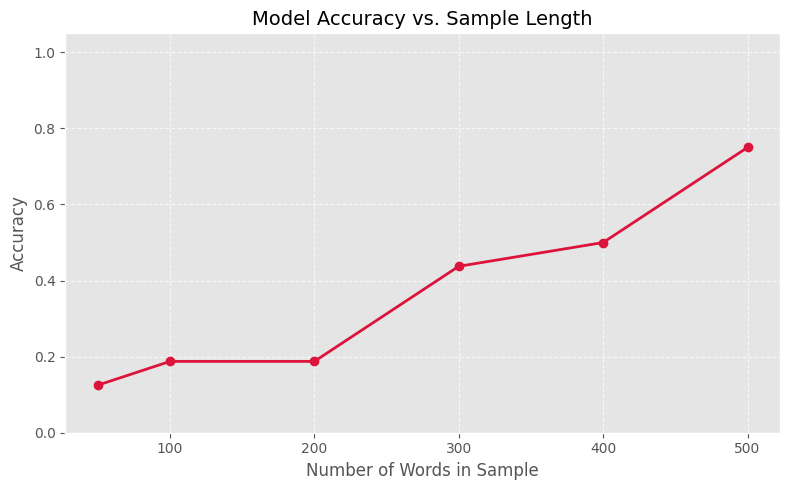

In [9]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from text_processor import extract_text_features

# Loading NLP model
nlp = spacy.load("pl_core_news_sm", disable=["ner"])

# Defining sample sizes 
word_limits = [50, 100, 200, 300, 400, 500]
accuracies = []

print("Starting Accuracy vs. Sample Length Experiment...\n")

for limit in word_limits:
    # Truncate texts to the current word limit
    truncated_texts = X_test['lyrics'].apply(lambda text: " ".join(text.split()[:limit]))
    
    # Re-extract stylometric features for the truncated texts.
    # This prevents data leakage by ensuring numeric features
    # like average sentence length or verb counts match the shortened text
    features_list = []
    for text in truncated_texts:
        features_list.append(extract_text_features(text, nlp))
        
    X_test_truncated = pd.concat(features_list, ignore_index=True)
    
    # Predicting
    y_pred_trunc = model_pipeline.predict(X_test_truncated)
    acc = accuracy_score(y_test, y_pred_trunc)
    accuracies.append(acc)
    
    # Printing result for the current text length
    print(f"Accuracy for {limit} words: {acc:.4f}")

# Ploting
plt.figure(figsize=(8, 5))
plt.plot(word_limits, accuracies, marker='o', linestyle='-', color='crimson', linewidth=2)

plt.title('Model Accuracy vs. Sample Length', fontsize=14)
plt.xlabel('Number of Words in Sample', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()